In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt

print("OSMnx:", ox.__version__)
print("NetworkX:", nx.__version__)

OSMnx: 2.1.1
NetworkX: 3.6.1


In [2]:
west = -124.20
south = 46.25
east = -123.85
north = 46.75

bbox = (west, south, east, north)

bbox

(-124.2, 46.25, -123.85, 46.75)

In [3]:
G_walk = ox.graph_from_bbox(
    bbox=bbox,
    network_type="walk",
    simplify=True,
    retain_all=True,
    truncate_by_edge=True
)

In [4]:
print("Nodes:", len(G_walk.nodes))
print("Edges:", len(G_walk.edges))
print("Graph type:", type(G_walk))

Nodes: 5451
Edges: 13330
Graph type: <class 'networkx.classes.multidigraph.MultiDiGraph'>


In [5]:
num_components = nx.number_weakly_connected_components(G_walk)

component_sizes = sorted(
    [len(component) for component in nx.weakly_connected_components(G_walk)],
    reverse=True
)

print("Weakly connected components:", num_components)
print("Largest component sizes:", component_sizes[:10])

Weakly connected components: 85
Largest component sizes: [4811, 325, 43, 35, 20, 9, 8, 8, 6, 6]


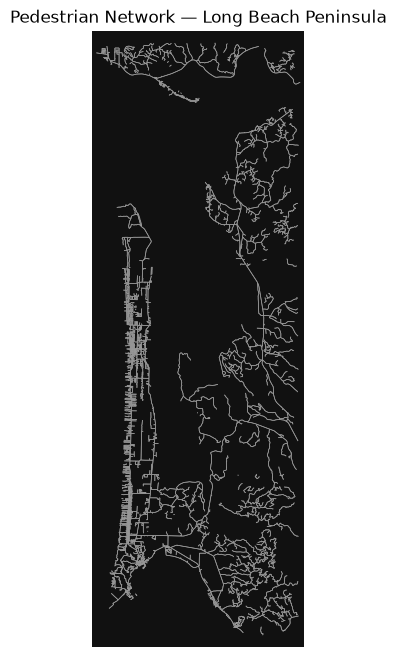

In [6]:
fig, ax = ox.plot_graph(
    G_walk,
    node_size=0,
    edge_linewidth=0.5,
    show=False,
    close=False
)

ax.set_title("Pedestrian Network — Long Beach Peninsula")
plt.show()

In [7]:
nodes, edges = ox.graph_to_gdfs(G_walk)

print("Nodes:", nodes.shape)
print("Edges:", edges.shape)

Nodes: (5451, 5)
Edges: (13330, 15)


In [8]:
edges.head()

osmid      highway                   name  oneway  \
u        v        key                                                           
50043501 50043503 0       6074580  residential     Idaho Avenue South   False   
         50135353 0       6074580  residential     Idaho Avenue South   False   
         50135728 0    1529315720  residential  15th Street Southeast   False   
50043503 50135824 0       6074580  residential     Idaho Avenue South   False   
         50043501 0       6074580  residential     Idaho Avenue South   False   

                      reversed      length  \
u        v        key                        
50043501 50043503 0      False   76.888788   
         50135353 0       True  150.332726   
         50135728 0       True   75.314602   
50043503 50135824 0      False   75.335327   
         50043501 0       True   76.888788   

                                                                geometry  \
u        v        key                                                      
50043501 50043503 0    LINESTRING (-124.05253 46.34256, -124.05251 46...   
         50135353 0    LINESTRING (-124.05253 46.34256, -124.05258 46...   
         50135728 0    LINESTRING (-124.05253 46.34256, -124.05351 46...   
50043503 50135824 0    LINESTRING (-124.05251 46.34325, -124.05251 46...   
         50043501 0    LINESTRING (-124.05251 46.34325, -124.05253 46...   

                      maxspeed service bridge lanes  ref tunnel access width  
u        v        key                                                         
50043501 50043503 0        NaN     NaN    NaN   NaN  NaN    NaN    NaN   NaN  
         50135353 0        NaN     NaN    NaN   NaN  NaN    NaN    NaN   NaN  
         50135728 0        NaN     NaN    NaN   NaN  NaN    NaN    NaN   NaN  
50043503 50135824 0        NaN     NaN    NaN   NaN  NaN    NaN    NaN   NaN  
         50043501 0        NaN     NaN    NaN   NaN  NaN    NaN    NaN   NaN

In [9]:
edges.columns.tolist()

['osmid',
 'highway',
 'name',
 'oneway',
 'reversed',
 'length',
 'geometry',
 'maxspeed',
 'service',
 'bridge',
 'lanes',
 'ref',
 'tunnel',
 'access',
 'width']

In [10]:
components = sorted(
    nx.weakly_connected_components(G_walk),
    key=len,
    reverse=True
)

node_to_component = {
    node: component_id
    for component_id, component in enumerate(components)
    for node in component
}

nodes["component_id"] = [
    node_to_component[node]
    for node in nodes.index
]

component_sizes = {
    component_id: len(component)
    for component_id, component in enumerate(components)
}

nodes["component_size"] = nodes["component_id"].map(component_sizes)

In [11]:
edges = edges.reset_index()

edges["component_id"] = edges["u"].map(node_to_component)

edges.head()

,u,v,key,osmid,highway,name,oneway,reversed,length,geometry,maxspeed,service,bridge,lanes,ref,tunnel,access,width,component_id
0,50043501,50043503,0,6074580,residential,Idaho Avenue South,False,False,76.888788,"LINESTRING (-124.05253 46.34256, -124.05251 46...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,50043501,50135353,0,6074580,residential,Idaho Avenue South,False,True,150.332726,"LINESTRING (-124.05253 46.34256, -124.05258 46...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,50043501,50135728,0,1529315720,residential,15th Street Southeast,False,True,75.314602,"LINESTRING (-124.05253 46.34256, -124.05351 46...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,50043503,50135824,0,6074580,residential,Idaho Avenue South,False,False,75.335327,"LINESTRING (-124.05251 46.34325, -124.05251 46...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,50043503,50043501,0,6074580,residential,Idaho Avenue South,False,True,76.888788,"LINESTRING (-124.05251 46.34325, -124.05253 46...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [12]:
def component_group(component_id):
    if component_id == 0:
        return "Largest component"
    elif component_id == 1:
        return "Second component"
    elif component_id == 2:
        return "Third component"
    else:
        return "Other"

edges["component_group"] = edges["component_id"].apply(component_group)

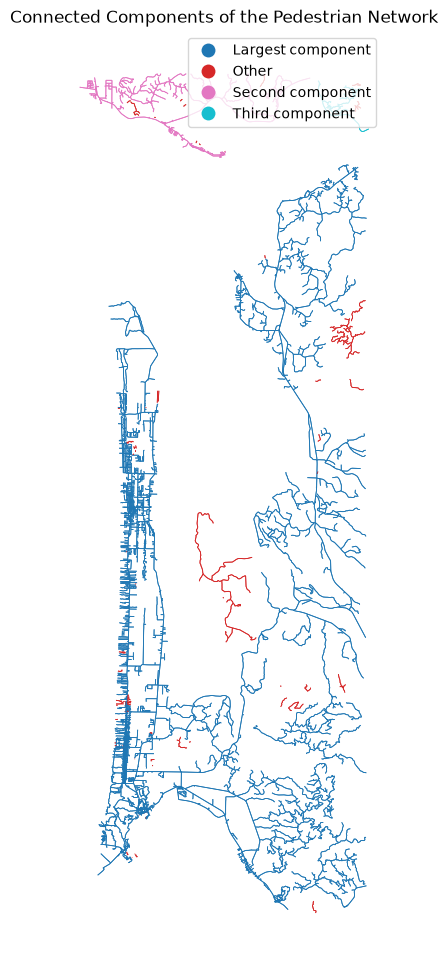

In [13]:
ax = edges.plot(
    column="component_group",
    categorical=True,
    legend=True,
    figsize=(9, 12),
    linewidth=0.6
)

ax.set_title("Connected Components of the Pedestrian Network")
ax.set_axis_off()

In [14]:
component_1_edges = edges[
    edges["component_id"] == 1
]

component_1_nodes = nodes[
    nodes["component_id"] == 1
]

print("Component 1 nodes:", len(component_1_nodes))
print("Component 1 edges:", len(component_1_edges))

Component 1 nodes: 325
Component 1 edges: 752


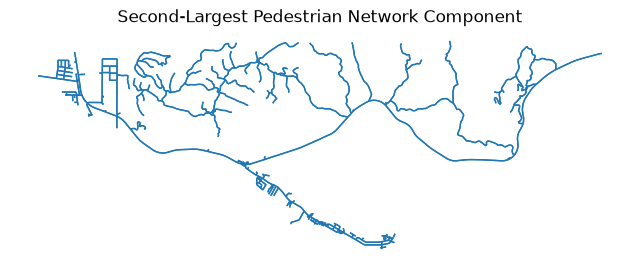

In [15]:
ax = component_1_edges.plot(
    figsize=(8, 8),
    linewidth=1
)

ax.set_title("Second-Largest Pedestrian Network Component")
ax.set_axis_off()

In [16]:
import pandas as pd

component_summary = []

for component_id, component in enumerate(components[:10]):
    component_nodes = nodes.loc[list(component)]

    bounds = component_nodes.total_bounds

    component_summary.append({
        "component_id": component_id,
        "nodes": len(component),
        "min_lon": bounds[0],
        "min_lat": bounds[1],
        "max_lon": bounds[2],
        "max_lat": bounds[3]
    })

component_summary = pd.DataFrame(component_summary)

component_summary

,component_id,nodes,min_lon,min_lat,max_lon,max_lat
0,0,4811,-124.079259,46.247396,-123.842178,46.698928
1,1,325,-124.095136,46.703826,-123.891982,46.755143
2,2,43,-123.884950,46.721185,-123.840330,46.750431
3,3,35,-123.874465,46.582230,-123.843463,46.606231
4,4,20,-123.989688,46.409687,-123.939449,46.481813
5,5,9,-123.852646,46.731678,-123.847285,46.737930
6,6,8,-124.033181,46.354193,-124.031355,46.354965
7,7,8,-124.053346,46.372153,-124.050468,46.377499
8,8,6,-124.061394,46.392050,-124.057869,46.392821
9,9,6,-124.026760,46.555073,-124.025348,46.562267


In [17]:
largest_share = len(components[0]) / len(G_walk.nodes)

print(f"Largest component share: {largest_share:.1%}")

Largest component share: 88.3%


In [18]:
component_1_edges[
    ["highway", "name", "length"]
].head(20)

,highway,name,length
57,secondary,State Route 105,72.928524
58,service,NaN,20.705284
59,secondary,State Route 105,90.932591
60,tertiary,Tokeland Road,50.385969
61,tertiary,Tokeland Road,97.313453
62,tertiary,Tokeland Road,50.385969
63,service,NaN,121.085669
64,residential,Shoalwater Bay Drive,63.122573
65,tertiary,Tokeland Road,287.223192
66,tertiary,Tokeland Road,97.313453


In [19]:
component_1_edges["highway"].value_counts().head(15)

highway
residential                      246
track                            180
service                          146
tertiary                          90
secondary                         60
unclassified                      14
footway                           12
[unclassified, footway]            2
[track, residential, service]      1
[residential, service, track]      1
Name: count, dtype: int64

In [20]:
place_query = "Long Beach Peninsula, Washington, USA"

peninsula = ox.geocode_to_gdf(place_query)

peninsula

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-124.07901 46.29872, -124.07899 46.2...",-124.079009,46.269938,-123.945187,46.662196,323453610,relation,15532796,46.466614,-124.042991,natural,peninsula,22,0.422134,peninsula,Long Beach Peninsula,"Long Beach Peninsula, Ocean Park, Pacific Coun..."


In [21]:
print(peninsula.geometry.geom_type)
print(peninsula.crs)

0    Polygon
dtype: str
epsg:4326


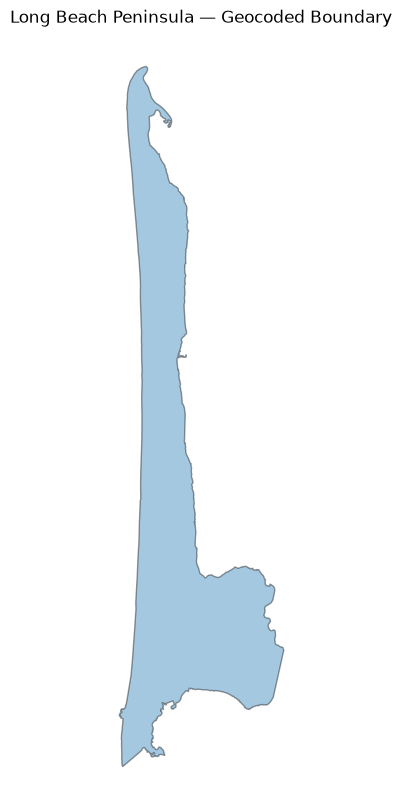

In [22]:
ax = peninsula.plot(
    figsize=(8, 10),
    edgecolor="black",
    alpha=0.4
)

ax.set_title("Long Beach Peninsula — Geocoded Boundary")
ax.set_axis_off()

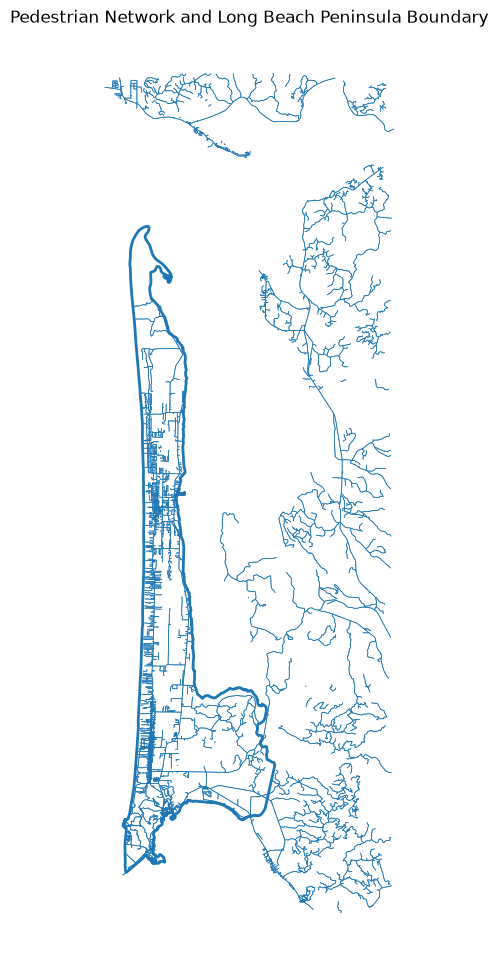

In [23]:
ax = edges.plot(
    figsize=(9, 12),
    linewidth=0.5
)

peninsula.boundary.plot(
    ax=ax,
    linewidth=2
)

ax.set_title("Pedestrian Network and Long Beach Peninsula Boundary")
ax.set_axis_off()

In [24]:
# Make sure both layers use the same CRS
peninsula = peninsula.to_crs(nodes.crs)

# Combine the peninsula geometry into one study-area geometry
study_geom = peninsula.geometry.union_all()

# Mark nodes located within or on the study-area boundary
nodes["in_study_area"] = nodes.geometry.covered_by(study_geom)

print("Total nodes:", len(nodes))
print("Nodes inside study area:", nodes["in_study_area"].sum())
print(
    "Share inside study area:",
    f"{nodes['in_study_area'].mean():.1%}"
)

Total nodes: 5451
Nodes inside study area: 3721
Share inside study area: 68.3%


In [25]:
study_node_ids = nodes.index[nodes["in_study_area"]]

G_peninsula = G_walk.subgraph(study_node_ids).copy()

print("Peninsula nodes:", len(G_peninsula.nodes))
print("Peninsula edges:", len(G_peninsula.edges))
print(
    "Weakly connected components:",
    nx.number_weakly_connected_components(G_peninsula)
)

Peninsula nodes: 3721
Peninsula edges: 9584
Weakly connected components: 49


In [26]:
peninsula_components = sorted(
    nx.weakly_connected_components(G_peninsula),
    key=len,
    reverse=True
)

peninsula_component_sizes = [
    len(component)
    for component in peninsula_components
]

print(
    "Largest peninsula component sizes:",
    peninsula_component_sizes[:10]
)

Largest peninsula component sizes: [3587, 8, 8, 6, 6, 6, 4, 4, 4, 4]


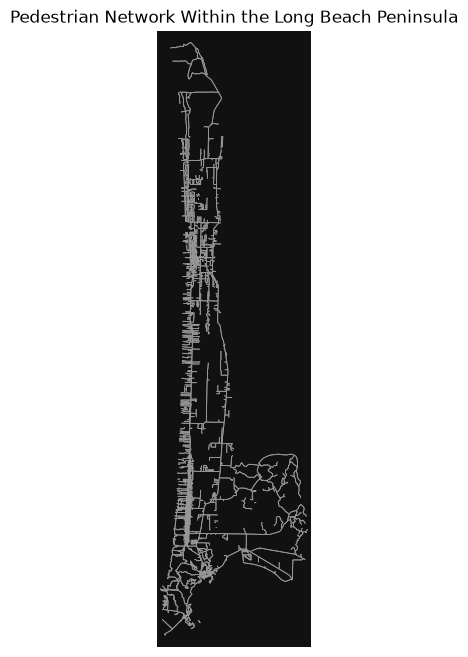

In [27]:
fig, ax = ox.plot_graph(
    G_peninsula,
    node_size=0,
    edge_linewidth=0.6,
    show=False,
    close=False
)

ax.set_title("Pedestrian Network Within the Long Beach Peninsula")
plt.show()

In [28]:
from pathlib import Path

project_root = Path.cwd().parent
raw_dir = project_root / "data" / "raw"

raw_graph_path = raw_dir / "osm_walk_network.graphml"

ox.save_graphml(
    G_walk,
    filepath=raw_graph_path
)

print(f"Saved raw network to: {raw_graph_path}")

Saved raw network to: /Users/zml/Desktop/Projects/tsunami-evacuation-resilience/data/raw/osm_walk_network.graphml


In [29]:
processed_dir = project_root / "data" / "processed"

boundary_path = (
    processed_dir / "long_beach_peninsula_boundary.geojson"
)

boundary_path.write_text(
    peninsula.to_json(),
    encoding="utf-8"
)

print(f"Saved boundary to: {boundary_path}")

Saved boundary to: /Users/zml/Desktop/Projects/tsunami-evacuation-resilience/data/processed/long_beach_peninsula_boundary.geojson
